# Challenge A — Late Refill Risk Prediction
**Pharmacy2U | DE-SynPUF Part D | Data & AI Hackathon**

**Goal**: Predict which patient-drug pairs are likely to refill late on their *next* fill, and produce a calibrated risk score.

**Pipeline**:
1. Load & label (build `is_late` target)
2. Feature engineering (refill cadence, patient history, cost signals)
3. Time-based train / test split (no leakage)
4. Baseline model (logistic regression)
5. Gradient boosting model (LightGBM)
6. Evaluation (PR-AUC, calibration, threshold tuning)
7. Explainability (SHAP)
8. Patient-level demo (timeline + risk score)

In [6]:
!pip install lightgbm shap --quiet

---
## 0. Setup

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    roc_auc_score, brier_score_loss, classification_report,
    ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve
import lightgbm as lgb
import shap
import joblib

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

GRACE_DAYS  = 14
RANDOM_SEED = 42
SPLIT_DATE  = '2009-07-01'  # train < split, test >= split

print('Setup complete')

Setup complete


---
## 1. Load Data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
link = '/content/drive/MyDrive/pharma2u/datasets/full_df_with_msr.parquet'


df = pd.read_parquet(link)

if df.index.name == 'DESYNPUF_ID':
    df = df.reset_index()

for col in ['SRVC_DT', 'BENE_DEATH_DT', 'BENE_BIRTH_DT']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

df = df.sort_values(['DESYNPUF_ID', 'INGREDIENT', 'SRVC_DT']).reset_index(drop=True)

print(f'Loaded : {len(df):,} rows | {df["DESYNPUF_ID"].nunique():,} patients | {df["INGREDIENT"].nunique():,} NDCs')
print(f'Dates  : {df["SRVC_DT"].min().date()} → {df["SRVC_DT"].max().date()}')
df.head(3)

Loaded : 5,373,237 rows | 92,118 patients | 10 NDCs
Dates  : 2008-01-01 → 2010-12-31


,DESYNPUF_ID,SRVC_DT,PROD_SRVC_ID,QTY_DSPNSD_NUM,DAYS_SUPLY_NUM,PTNT_PAY_AMT,TOT_RX_CST_AMT,days_supply_missing_flag,BENE_BIRTH_DT,BENE_DEATH_DT,BENE_SEX_IDENT_CD,BENE_RACE_CD,BENE_ESRD_IND,SP_STATE_CODE,BENE_COUNTY_CD,SP_ALZHDMTA,SP_CHF,SP_CHRNKIDN,SP_CNCR,SP_COPD,SP_DEPRESSN,SP_DIABETES,SP_ISCHMCHT,SP_OSTEOPRS,SP_RA_OA,SP_STRKETIA,Age,has_death_record,comorbidity_count,cat_heart,cat_kidney_metabolic,cat_neuro_mental,cat_musculoskeletal,is_frail,flag_behavioral_complication,flag_triad_risk,insurance_benefit_amt,oop_ratio,log_ptnt_pay,log_tot_cst,flag_high_financial_barrier,MANUFACTURER,INGREDIENT,STRENGTH,DOSAGE,ROUTE_ADMIN,PACKAGING,MISSES,RUN_OUT_DATE,next_fill_dt,gap_days,msr_start_dt,msr_end_dt,msr_end_dt_default,msr_end_dt_adjusted,flag_prescription_too_late_after_death
0,00013D2EFD8E45D1,2008-01-03,00247037252,30.0,20.0,10.0,120.0,0,1923-05-01,NaT,1,1,0,26,950,0,1,0,0,0,0,0,0,1,0,0,84,0,2,1,0,0,1,0,0,0,110.0,0.083333,2.397895,4.795791,0,00247,0,3,7,2,52,In time,2008-01-23,2008-01-05,-18.0,2008-01-03,2010-09-09,2009-01-02,2009-01-02,0
1,00013D2EFD8E45D1,2008-01-05,00223039502,10.0,10.0,0.0,0.0,0,1923-05-01,NaT,1,1,0,26,950,0,1,0,0,0,0,0,0,1,0,0,84,0,2,1,0,0,1,0,0,0,0.0,0.000000,0.000000,0.000000,0,00223,0,3,9,5,02,In time,2008-01-15,2008-01-24,9.0,2008-01-03,2010-09-09,2009-01-02,2009-01-02,0
2,00013D2EFD8E45D1,2008-01-24,58016005300,30.0,30.0,70.0,70.0,0,1923-05-01,NaT,1,1,0,26,950,0,1,0,0,0,0,0,0,1,0,0,84,0,2,1,0,0,1,0,0,0,0.0,1.000000,4.262680,4.262680,1,58016,0,0,5,3,00,In time,2008-02-23,2008-01-24,-30.0,2008-01-03,2010-09-09,2009-01-02,2009-01-02,0


---
## 2. Build Target Variable — `is_late`

```
run_out_dt  = SRVC_DT + DAYS_SUPLY_NUM
gap_days    = next_fill_SRVC_DT − run_out_dt
is_late     = gap_days > GRACE_DAYS
```

Last fills per patient-drug are censored (no next fill exists) and excluded from modelling.

In [4]:
df['run_out_dt']   = df['SRVC_DT'] + pd.to_timedelta(df['DAYS_SUPLY_NUM'].fillna(0), unit='d')
df['next_fill_dt'] = df.groupby(['DESYNPUF_ID', 'INGREDIENT'])['SRVC_DT'].shift(-1)
df['gap_days']     = (df['next_fill_dt'] - df['run_out_dt']).dt.days
df['is_late']      = (df['gap_days'] > GRACE_DAYS).astype('Int8')

labelled = df.dropna(subset=['is_late']).copy()
labelled['is_late'] = labelled['is_late'].astype(int)

late_rate = labelled['is_late'].mean() * 100
print(f'Labelled fills  : {len(labelled):,}')
print(f'Censored (last) : {df["is_late"].isna().sum():,}')
print(f'Late rate       : {late_rate:.1f}%  (grace = {GRACE_DAYS} days)')
print(f'Class balance   : {labelled["is_late"].value_counts().to_dict()}')

Labelled fills  : 5,373,237
Censored (last) : 0
Late rate       : 23.3%  (grace = 14 days)
Class balance   : {0: 4118657, 1: 1254580}


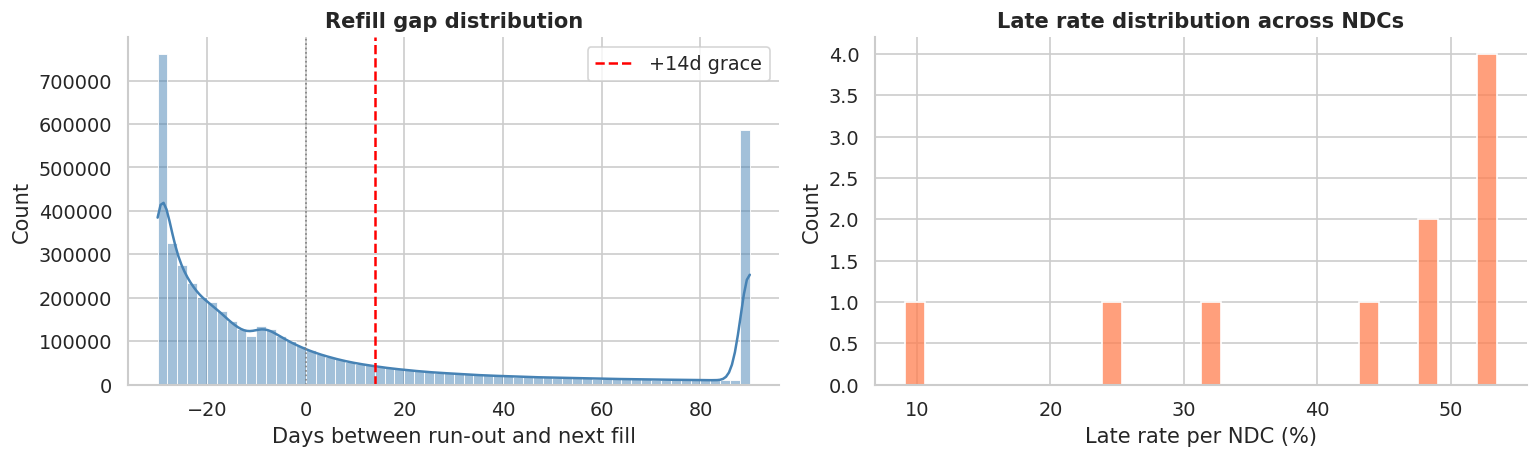

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(labelled['gap_days'].clip(-30, 90), bins=60, kde=True,
             color='steelblue', ax=axes[0])
axes[0].axvline(GRACE_DAYS, color='red', lw=1.5, linestyle='--',
                label=f'+{GRACE_DAYS}d grace')
axes[0].axvline(0, color='grey', lw=1, linestyle=':')
axes[0].set_title('Refill gap distribution', fontweight='bold')
axes[0].set_xlabel('Days between run-out and next fill')
axes[0].legend()

late_by_drug = labelled.groupby('INGREDIENT')['is_late'].mean().sort_values(ascending=False)
sns.histplot(late_by_drug * 100, bins=30, color='coral', ax=axes[1])
axes[1].set_title('Late rate distribution across NDCs', fontweight='bold')
axes[1].set_xlabel('Late rate per NDC (%)')

plt.tight_layout()
plt.show()

---
## 3. Feature Engineering

All features use **only information available before the next fill** (no future leakage).

### Lag features (previous fill):

`prev_gap_days`: The gap in days between the previous fill's run-out date and its next fill date for the same patient and drug. This indicates the refill pattern of the immediately preceding prescription.
`prev_days_supply:` The number of days' supply for the immediately preceding prescription.
`prev_tot_cost`: The total cost of the immediately preceding prescription.
`prev_ptnt_pay`: The patient's payment amount for the immediately preceding prescription. These features capture the immediate history of the patient-drug interaction, which can be highly predictive of future behavior.

### Rolling cadence statistics (last 3 fills):

`rolling_gap_mean`: The average gap_days over the last three fills for the same patient and drug. This provides a smoothed view of the patient's typical refill cadence.
`rolling_gap_std`: The standard deviation of gap_days over the last three fills for the same patient and drug. This measures the consistency or variability in the patient's refill pattern.

### Fill tenure:

`fill_number`: This represents the sequential number of the current prescription fill for a specific patient and drug. For example, the first time a patient gets a particular drug, this would be 1, the second time 2, and so on. This feature can indicate patient loyalty to a drug or the chronicity of their condition requiring that medication.

### Stockpiling:

`prev_was_early`: A binary indicator (1 or 0) that flags whether the previous fill was significantly early (more than 7 days before the run-out date). This can signal patient behavior like stockpiling medications.

### Polypharmacy:

`n_unique_drugs`: The number of distinct drugs (INGREDIENTs) a patient (DESYNPUF_ID) has been prescribed. This feature quantifies polypharmacy, which can be an indicator of patient health complexity or medication burden.

###Temporal features:

`fill_month`: The month in which the prescription was filled.
`fill_quarter`: The quarter of the year in which the prescription was filled.
`is_year_end_q`: A binary indicator (1 or 0) for whether the fill occurred in the last quarter of the year. These temporal features can capture seasonal patterns or behavioral changes around certain times of the year (e.g., holidays, insurance changes).

### Derived cost features:

`oop_ratio`: The ratio of the patient's out-of-pocket payment (PTNT_PAY_AMT) to the total prescription cost (TOT_RX_CST_AMT).
`log_tot_cst`: The natural logarithm of TOT_RX_CST_AMT (plus one to handle zero values).
`log_ptnt_pay`: The natural logarithm of PTNT_PAY_AMT (plus one to handle zero values). These features provide alternative representations of cost that might better capture its relationship with refill behavior or handle skewed distributions.





In [7]:
grp = labelled.groupby(['DESYNPUF_ID', 'INGREDIENT'])

# ── Lag features (previous fill) ─────────────────────────────────────────────
labelled['prev_gap_days']    = grp['gap_days'].shift(1)
labelled['prev_days_supply'] = grp['DAYS_SUPLY_NUM'].shift(1)
labelled['prev_tot_cost']    = grp['TOT_RX_CST_AMT'].shift(1)
labelled['prev_ptnt_pay']    = grp['PTNT_PAY_AMT'].shift(1)

# ── Rolling cadence stats (last 3 fills) ──────────────────────────────────────
labelled['rolling_gap_mean'] = grp['gap_days'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
)
labelled['rolling_gap_std'] = grp['gap_days'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=2).std()
)

# ── Fill tenure ───────────────────────────────────────────────────────────────
labelled['fill_number'] = grp.cumcount() + 1

# ── Stockpiling: previous fill was early (gap < -7 days) ─────────────────────
labelled['prev_was_early'] = (labelled['prev_gap_days'] < -7).astype('Int8')

# ── Polypharmacy ──────────────────────────────────────────────────────────────
labelled['n_unique_drugs'] = labelled.groupby('DESYNPUF_ID')['INGREDIENT'].transform('nunique')

# ── Temporal features ────────────────────────────────────────────────────────
labelled['fill_month']    = labelled['SRVC_DT'].dt.month
labelled['fill_quarter']  = labelled['SRVC_DT'].dt.quarter
labelled['is_year_end_q'] = (labelled['fill_quarter'] == 4).astype(int)

# ── Derived cost features (re-derive if not present) ─────────────────────────
if 'oop_ratio' not in labelled.columns:
    labelled['oop_ratio'] = np.where(
        labelled['TOT_RX_CST_AMT'] > 0,
        labelled['PTNT_PAY_AMT'] / labelled['TOT_RX_CST_AMT'], 0
    ).clip(0, 1)

if 'log_tot_cst' not in labelled.columns:
    labelled['log_tot_cst']  = np.log1p(labelled['TOT_RX_CST_AMT'])
    labelled['log_ptnt_pay'] = np.log1p(labelled['PTNT_PAY_AMT'])

print(f'Feature engineering complete. Shape: {labelled.shape}')

Feature engineering complete. Shape: (5373237, 70)


In [9]:
FEATURE_COLS = [
    # Dispensing
    'DAYS_SUPLY_NUM', 'QTY_DSPNSD_NUM', 'fill_number',
    # Cadence history
    'prev_gap_days', 'prev_days_supply', 'rolling_gap_mean', 'rolling_gap_std',
    'prev_was_early',
    # Cost
    'log_tot_cst', 'log_ptnt_pay', 'oop_ratio',
    'prev_tot_cost', 'prev_ptnt_pay',
    # Patient
    'Age', 'BENE_SEX_IDENT_CD', 'BENE_RACE_CD',
    # Comorbidities
    'comorbidity_count', 'is_frail',
    'cat_heart', 'cat_kidney_metabolic', 'cat_neuro_mental', 'cat_musculoskeletal',
    'flag_behavioral_complication', 'flag_triad_risk',
    # Polypharmacy & timing
    'n_unique_drugs', 'fill_month', 'is_year_end_q',
    # Data quality
   # 'days_supply_missing_flag',
]
FEATURE_COLS = [c for c in FEATURE_COLS if c in labelled.columns]

# Convert category cols to numeric codes
for col in ['BENE_SEX_IDENT_CD', 'BENE_RACE_CD']:
    if col in labelled.columns:
        labelled[col] = labelled[col].astype(str).astype('category').cat.codes

# Impute lag features (NaN on first fill per patient-drug)
lag_cols = ['prev_gap_days', 'prev_days_supply', 'prev_tot_cost',
            'prev_ptnt_pay', 'rolling_gap_mean', 'rolling_gap_std', 'prev_was_early']
for col in lag_cols:
    if col in labelled.columns:
        labelled[col] = labelled[col].fillna(0)

if 'Age' in labelled.columns:
    labelled['Age'] = labelled['Age'].fillna(labelled['Age'].median())

print(f'Features: {len(FEATURE_COLS)}')
remaining_miss = labelled[FEATURE_COLS].isnull().sum()
print('Remaining NaN:', remaining_miss[remaining_miss > 0].to_dict() or 'none')

Features: 27
Remaining NaN: none


---
## 4. Time-Based Train / Test Split

In [10]:
train = labelled[labelled['SRVC_DT'] <  SPLIT_DATE]
test  = labelled[labelled['SRVC_DT'] >= SPLIT_DATE]

X_train, y_train = train[FEATURE_COLS], train['is_late']
X_test,  y_test  = test[FEATURE_COLS],  test['is_late']

print(f'Train : {len(train):,} rows | late rate {y_train.mean()*100:.1f}%')
print(f'Test  : {len(test):,}  rows | late rate {y_test.mean()*100:.1f}%')

train_pts = set(train['DESYNPUF_ID'])
test_pts  = set(test['DESYNPUF_ID'])
print(f'Patients in both sets   : {len(train_pts & test_pts):,}')
print(f'Patients in test only   : {len(test_pts - train_pts):,}  (cold-start patients)')

Train : 2,959,921 rows | late rate 28.0%
Test  : 2,413,316  rows | late rate 17.6%
Patients in both sets   : 76,577
Patients in test only   : 11,530  (cold-start patients)


---
## 5. Baseline — Logistic Regression

In [11]:
baseline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=1000, class_weight='balanced',
                                   random_state=RANDOM_SEED))
])
baseline.fit(X_train, y_train)
y_prob_base = baseline.predict_proba(X_test)[:, 1]

pr_auc_base  = average_precision_score(y_test, y_prob_base)
roc_auc_base = roc_auc_score(y_test, y_prob_base)
print(f'Baseline  PR-AUC : {pr_auc_base:.4f}')
print(f'Baseline ROC-AUC : {roc_auc_base:.4f}')
print(f'Baseline Brier   : {brier_score_loss(y_test, y_prob_base):.4f}')

Baseline  PR-AUC : 0.3258
Baseline ROC-AUC : 0.7700
Baseline Brier   : 0.1986


---
## 6. LightGBM Model

In [12]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

lgbm = lgb.LGBMClassifier(
    n_estimators      = 500,
    learning_rate     = 0.05,
    num_leaves        = 63,
    min_child_samples = 50,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = scale_pos_weight,
    random_state      = RANDOM_SEED,
    n_jobs            = -1,
    verbose           = -1,
)

lgbm.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[
        lgb.early_stopping(50, verbose=False),
        lgb.log_evaluation(100)
    ]
)

y_prob_lgbm  = lgbm.predict_proba(X_test)[:, 1]
pr_auc_lgbm  = average_precision_score(y_test, y_prob_lgbm)
roc_auc_lgbm = roc_auc_score(y_test, y_prob_lgbm)

print(f'LightGBM best iteration : {lgbm.best_iteration_}')
print(f'LightGBM  PR-AUC  : {pr_auc_lgbm:.4f}  (baseline: {pr_auc_base:.4f})')
print(f'LightGBM ROC-AUC  : {roc_auc_lgbm:.4f}  (baseline: {roc_auc_base:.4f})')
print(f'LightGBM Brier    : {brier_score_loss(y_test, y_prob_lgbm):.4f}')

LightGBM best iteration : 12
LightGBM  PR-AUC  : 0.3588  (baseline: 0.3258)
LightGBM ROC-AUC  : 0.7802  (baseline: 0.7700)
LightGBM Brier    : 0.1415


---
## 7. Evaluation

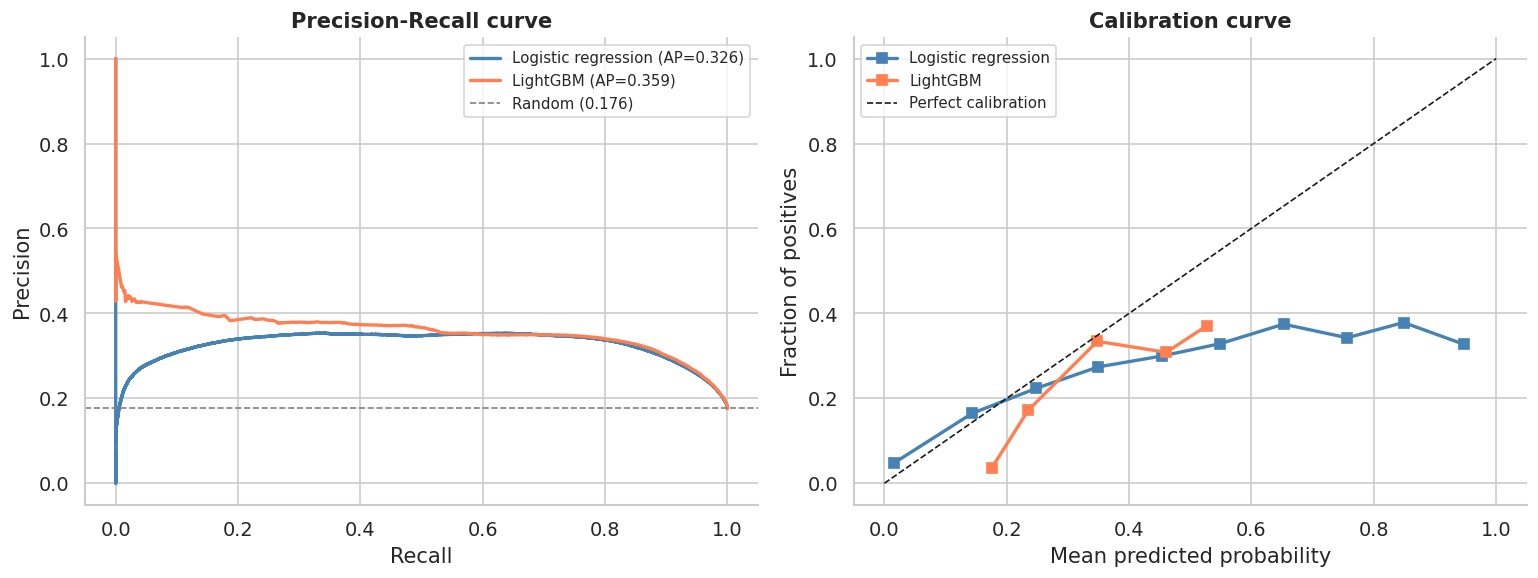

In [13]:
# ── PR curve + calibration ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for label, y_prob, color in [
    ('Logistic regression', y_prob_base, 'steelblue'),
    ('LightGBM',            y_prob_lgbm, 'coral'),
]:
    p, r, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    axes[0].plot(r, p, label=f'{label} (AP={ap:.3f})', color=color, lw=2)

axes[0].axhline(y_test.mean(), color='grey', lw=1, linestyle='--',
                label=f'Random ({y_test.mean():.3f})')
axes[0].set_title('Precision-Recall curve', fontweight='bold')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].legend(fontsize=9)

for label, y_prob, color in [
    ('Logistic regression', y_prob_base, 'steelblue'),
    ('LightGBM',            y_prob_lgbm, 'coral'),
]:
    frac_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=10)
    axes[1].plot(mean_pred, frac_pos, 's-', label=label, color=color, lw=2, ms=6)

axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
axes[1].set_title('Calibration curve', fontweight='bold')
axes[1].set_xlabel('Mean predicted probability')
axes[1].set_ylabel('Fraction of positives')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

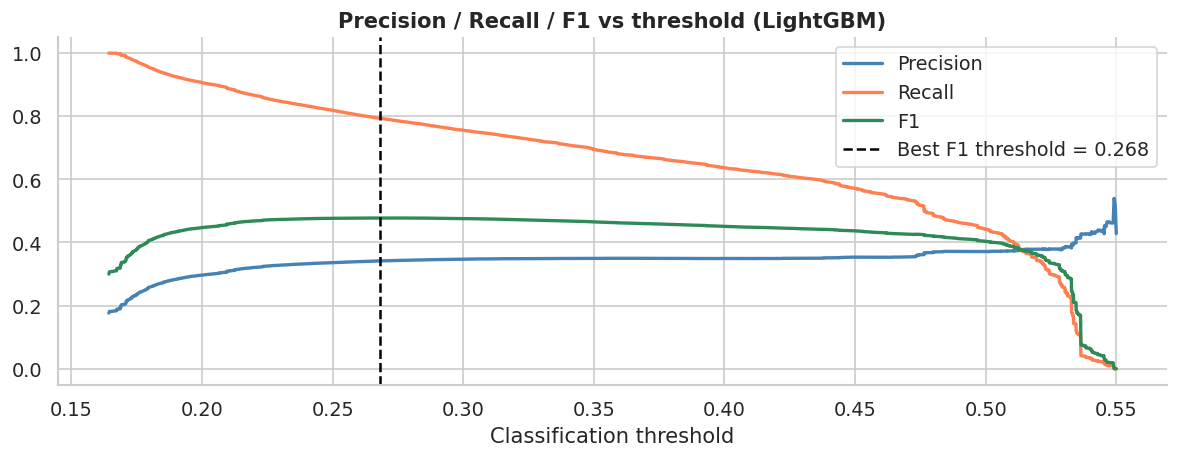

Best threshold : 0.268
  Precision    : 0.342
  Recall       : 0.794
  F1           : 0.478


In [14]:
# ── Threshold tuning ──────────────────────────────────────────────────────────
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_lgbm)
f1_scores      = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-8)
best_idx       = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, precisions[:-1], label='Precision', color='steelblue', lw=2)
ax.plot(thresholds, recalls[:-1],    label='Recall',    color='coral',     lw=2)
ax.plot(thresholds, f1_scores,       label='F1',        color='seagreen',  lw=2)
ax.axvline(best_threshold, color='black', lw=1.5, linestyle='--',
           label=f'Best F1 threshold = {best_threshold:.3f}')
ax.set_title('Precision / Recall / F1 vs threshold (LightGBM)', fontweight='bold')
ax.set_xlabel('Classification threshold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Best threshold : {best_threshold:.3f}')
print(f'  Precision    : {precisions[best_idx]:.3f}')
print(f'  Recall       : {recalls[best_idx]:.3f}')
print(f'  F1           : {f1_scores[best_idx]:.3f}')

              precision    recall  f1-score   support

     On time       0.94      0.67      0.78   1987566
        Late       0.34      0.79      0.48    425750

    accuracy                           0.69   2413316
   macro avg       0.64      0.73      0.63   2413316
weighted avg       0.83      0.69      0.73   2413316



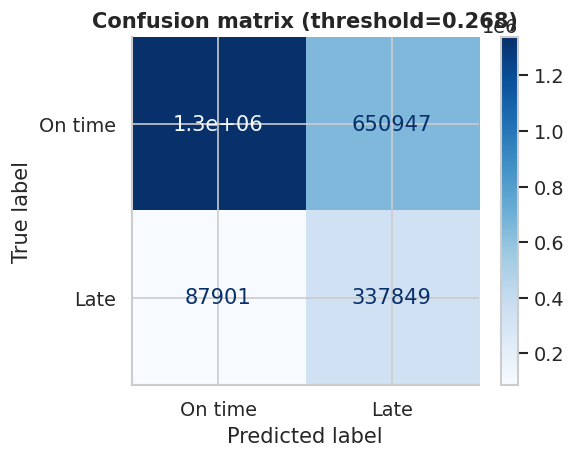

In [15]:
y_pred_lgbm = (y_prob_lgbm >= best_threshold).astype(int)

print(classification_report(y_test, y_pred_lgbm, target_names=['On time', 'Late']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lgbm,
    display_labels=['On time', 'Late'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Confusion matrix (threshold={best_threshold:.3f})', fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
summary = pd.DataFrame([
    {'Model': 'Random (naive)',      'PR-AUC': round(y_test.mean(), 4), 'ROC-AUC': 0.5,               'Brier': None},
    {'Model': 'Logistic Regression', 'PR-AUC': round(pr_auc_base, 4),  'ROC-AUC': round(roc_auc_base, 4), 'Brier': round(brier_score_loss(y_test, y_prob_base), 4)},
    {'Model': 'LightGBM',            'PR-AUC': round(pr_auc_lgbm, 4),  'ROC-AUC': round(roc_auc_lgbm, 4), 'Brier': round(brier_score_loss(y_test, y_prob_lgbm), 4)},
]).set_index('Model')

display(summary.style
    .highlight_max(subset=['PR-AUC', 'ROC-AUC'], color='#d4edda')
    .highlight_min(subset=['Brier'],              color='#d4edda', axis=0))

,PR-AUC,ROC-AUC,Brier
Model,,,
Random (naive),0.176400,0.500000,nan
Logistic Regression,0.325800,0.770000,0.198600
LightGBM,0.358800,0.780200,0.141500


---
## 8. Explainability — SHAP

In [17]:
shap_sample = X_test.sample(min(5000, len(X_test)), random_state=RANDOM_SEED)
explainer   = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(shap_sample)

# LightGBM binary returns list [neg_class, pos_class]
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

print(f'SHAP values computed on {len(shap_sample):,} samples')

SHAP values computed on 5,000 samples


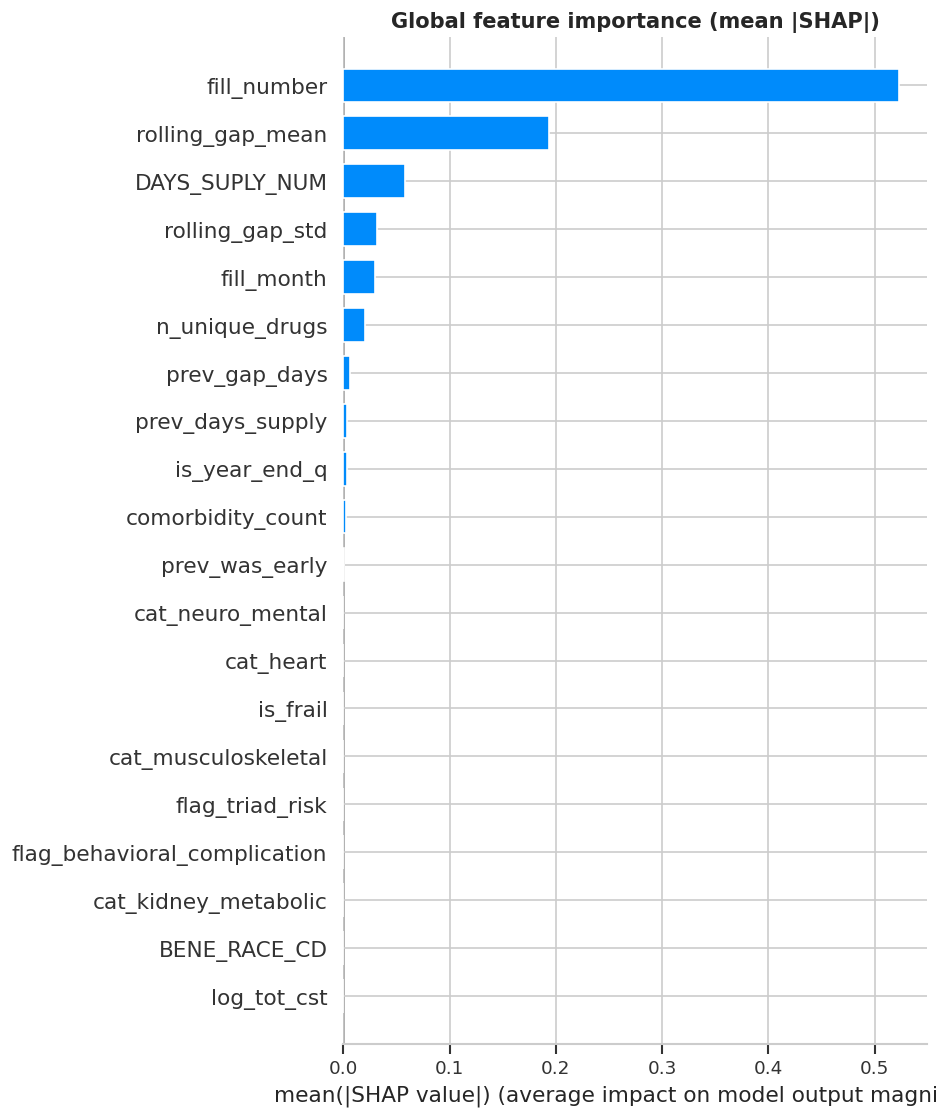

In [18]:
# Global importance (bar)
shap.summary_plot(sv, shap_sample, feature_names=FEATURE_COLS,
                  plot_type='bar', max_display=20, show=False)
plt.title('Global feature importance (mean |SHAP|)', fontweight='bold')
plt.tight_layout()
plt.show()

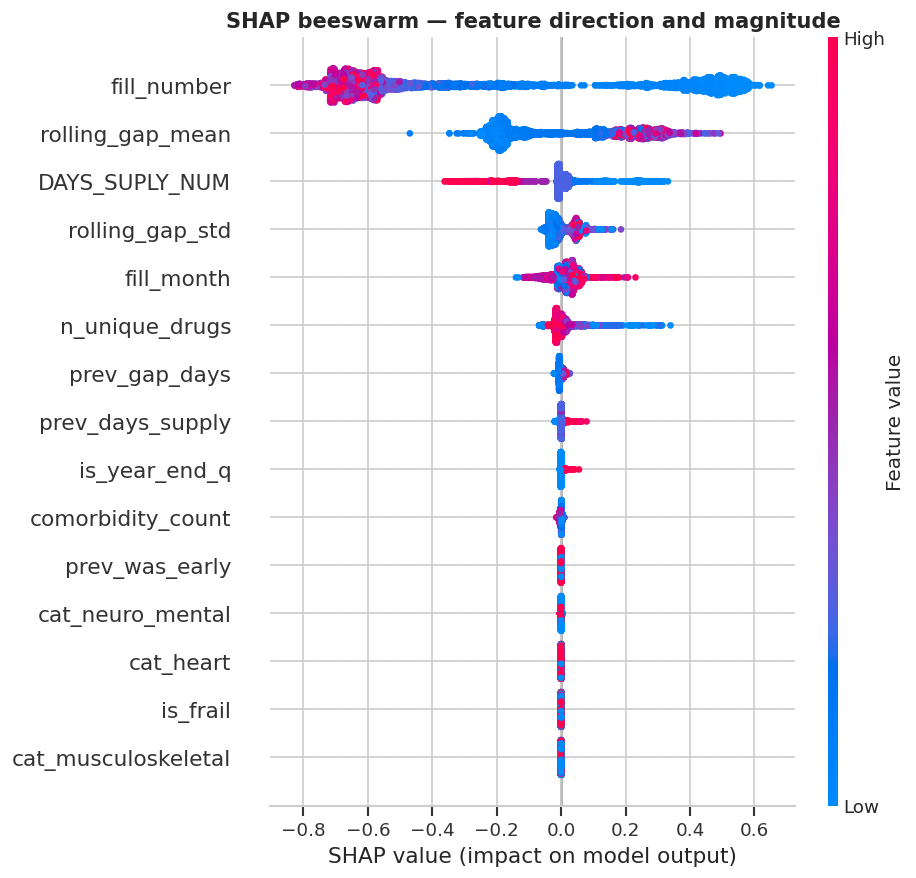

In [19]:
# Beeswarm — direction and spread
shap.summary_plot(sv, shap_sample, feature_names=FEATURE_COLS,
                  max_display=15, show=False)
plt.title('SHAP beeswarm — feature direction and magnitude', fontweight='bold')
plt.tight_layout()
plt.show()

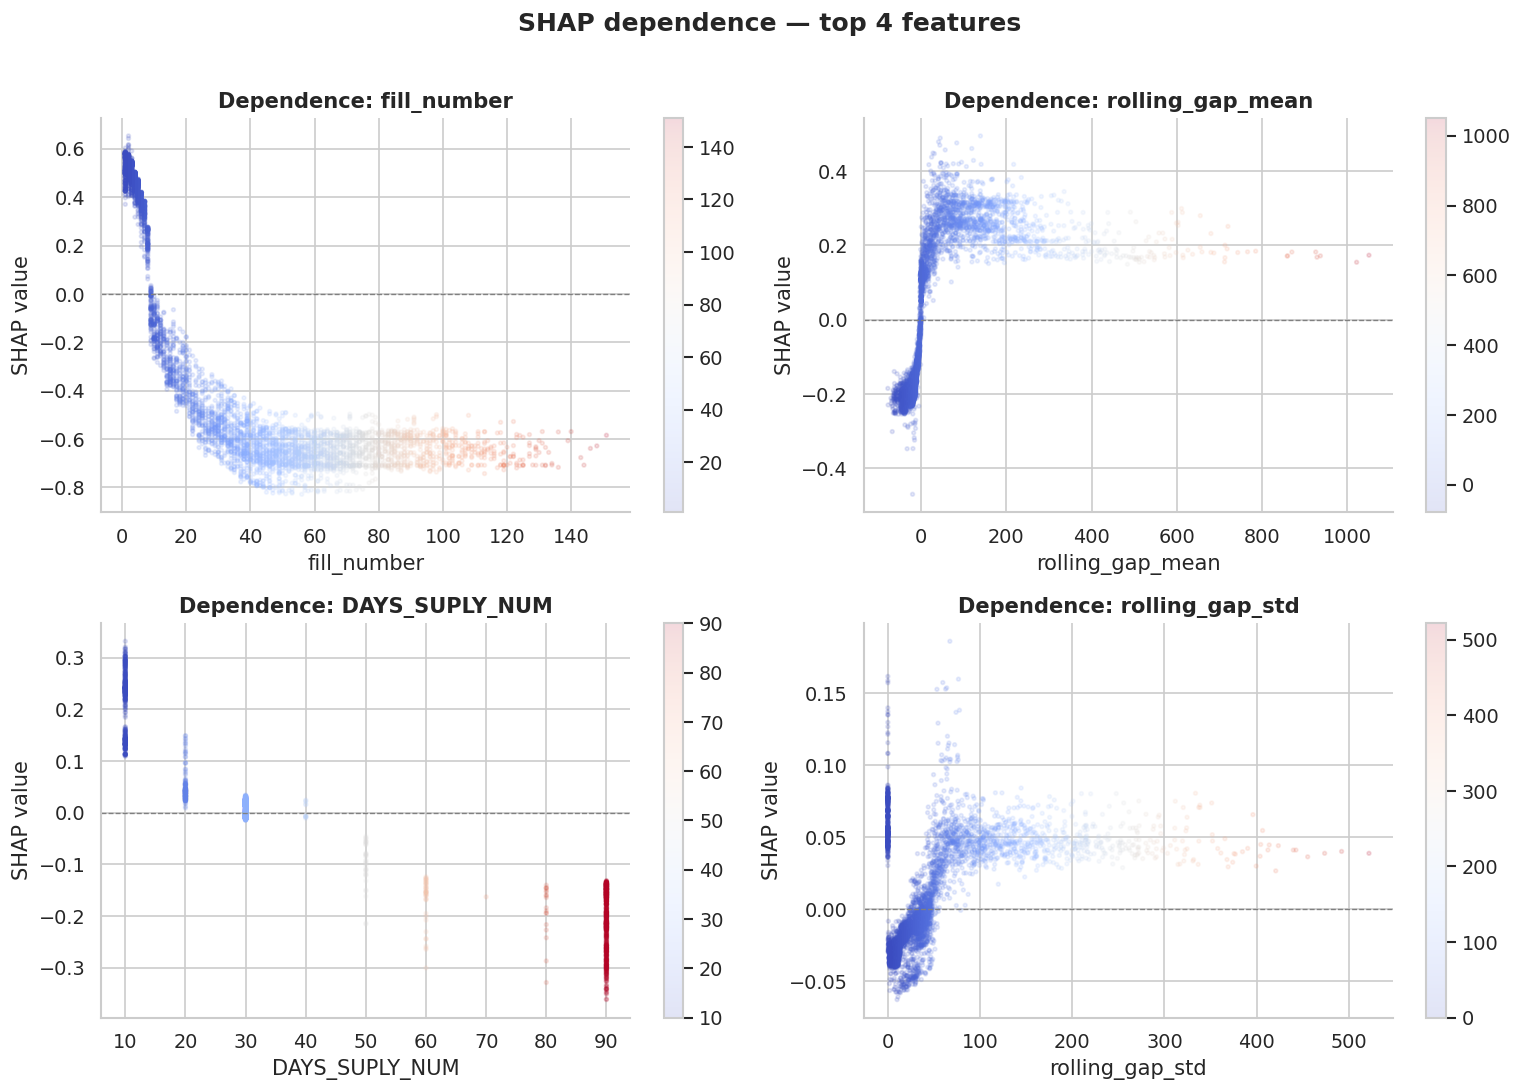

In [20]:
# Top-4 dependence plots
mean_abs_shap = np.abs(sv).mean(axis=0)
top_features  = [FEATURE_COLS[i] for i in np.argsort(mean_abs_shap)[::-1][:4]]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, feat in zip(axes.flatten(), top_features):
    idx  = FEATURE_COLS.index(feat)
    vals = shap_sample[feat].values
    sc   = ax.scatter(vals, sv[:, idx], c=vals, cmap='coolwarm', alpha=0.15, s=5)
    ax.axhline(0, color='grey', lw=0.8, linestyle='--')
    ax.set_xlabel(feat); ax.set_ylabel('SHAP value')
    ax.set_title(f'Dependence: {feat}', fontweight='bold')
    plt.colorbar(sc, ax=ax)

plt.suptitle('SHAP dependence — top 4 features', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 9. Patient-Level Risk Scores & Demo

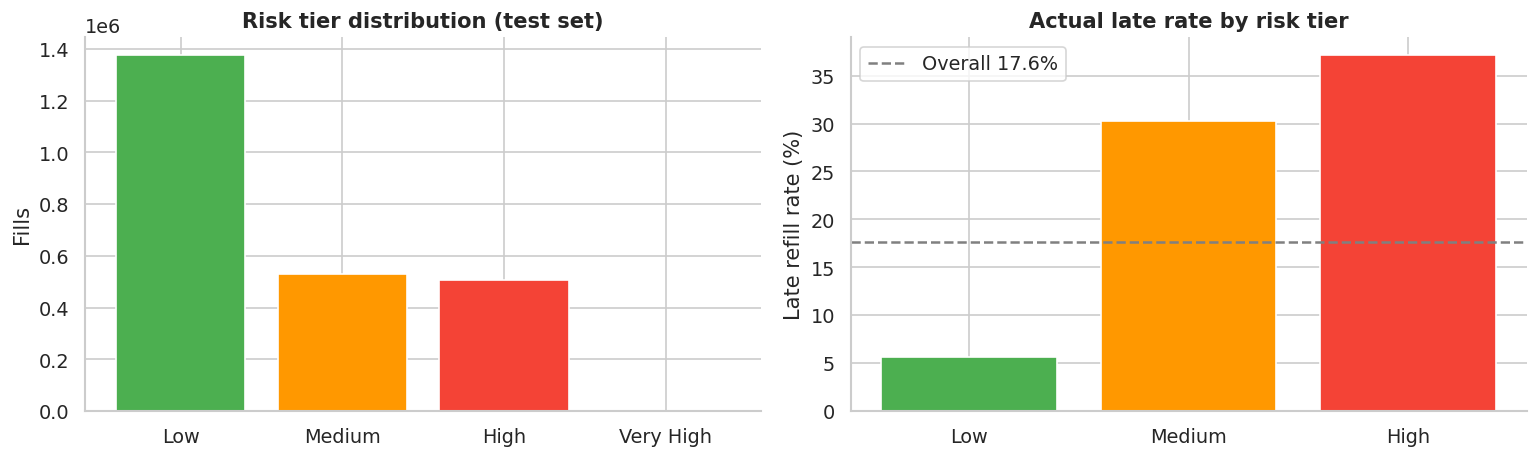

In [21]:
test_scored = test.copy()
test_scored['risk_score'] = y_prob_lgbm
test_scored['risk_flag']  = (y_prob_lgbm >= best_threshold).astype(int)
test_scored['risk_tier']  = pd.cut(
    test_scored['risk_score'],
    bins=[0, 0.25, 0.50, 0.75, 1.0],
    labels=['Low', 'Medium', 'High', 'Very High'],
    include_lowest=True
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
tier_order  = ['Low', 'Medium', 'High', 'Very High']
tier_colors = ['#4caf50', '#ff9800', '#f44336', '#b71c1c']

tier_counts = test_scored['risk_tier'].value_counts().reindex(tier_order)
axes[0].bar(tier_counts.index, tier_counts.values, color=tier_colors)
axes[0].set_title('Risk tier distribution (test set)', fontweight='bold')
axes[0].set_ylabel('Fills')

late_by_tier = test_scored.groupby('risk_tier', observed=True)['is_late'].mean() * 100
late_by_tier = late_by_tier.reindex(tier_order)
axes[1].bar(late_by_tier.index, late_by_tier.values, color=tier_colors)
axes[1].axhline(y_test.mean() * 100, color='grey', lw=1.5, linestyle='--',
                label=f'Overall {y_test.mean()*100:.1f}%')
axes[1].set_title('Actual late rate by risk tier', fontweight='bold')
axes[1].set_ylabel('Late refill rate (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [23]:
def patient_timeline(patient_id: str, max_drugs: int = 4):
    """Plot prescription timeline with risk scores for one patient."""
    pt = test_scored[test_scored['DESYNPUF_ID'] == patient_id].copy()
    if pt.empty:
        print(f'Patient {patient_id} not found in test set.')
        return

    drugs = pt['INGREDIENT'].value_counts().head(max_drugs).index.tolist()
    pt    = pt[pt['INGREDIENT'].isin(drugs)]
    cmap  = plt.cm.RdYlGn_r

    fig, ax = plt.subplots(figsize=(14, max(3, len(drugs) * 1.5)))

    for i, drug in enumerate(drugs):
        fills = pt[pt['INGREDIENT'] == drug].sort_values('SRVC_DT')
        for _, row in fills.iterrows():
            color    = cmap(row['risk_score'])
            duration = max((row['run_out_dt'] - row['SRVC_DT']).days, 1)
            ax.barh(i, duration, left=row['SRVC_DT'], height=0.5,
                    color=color, alpha=0.85, edgecolor='white', lw=0.5)
            ax.text(row['SRVC_DT'], i + 0.32,
                    f"{row['risk_score']:.2f}", fontsize=7, va='bottom')
            if row['is_late'] == 1:
                ax.plot(row['run_out_dt'], i, 'rx', ms=9, mew=2)

    ax.set_yticks(range(len(drugs)))
    ax.set_yticklabels([f'NDC …{d[-6:]}' for d in drugs], fontsize=9)
    ax.set_xlabel('Date')
    ax.set_title(f'Patient {patient_id[:12]}… — timeline & late refill risk',
                 fontweight='bold')

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label='Risk score (0 = on-time, 1 = late)', shrink=0.6)

    legend_handles = [
        plt.Line2D([0], [0], marker='x', color='red', lw=0, ms=9, mew=2,
                   label='Actual late fill')
    ]
    ax.legend(handles=legend_handles, fontsize=9)
    plt.tight_layout()
    plt.show()

    display(
        pt[['SRVC_DT', 'INGREDIENT', 'DAYS_SUPLY_NUM',
            'gap_days', 'is_late', 'risk_score', 'risk_tier']]
        .sort_values('SRVC_DT')
        .style
        .background_gradient(subset=['risk_score'], cmap='RdYlGn_r')
        .format({'risk_score': '{:.3f}', 'gap_days': '{:.0f}'})
    )

Top 10 highest mean risk patients:
DESYNPUF_ID
EED095CC13ED255E    0.538582
075DFFD25320EE86    0.537466
5C849AF870B87B14    0.535198
9DDA09C6FA848631    0.532884
FE19354018A14CB9    0.532884
FE37F6902C894373    0.532884
5DA351CF78AA7D6E    0.532884
ABCC02276D435679    0.532884
13216B222FABF312    0.532884
B84897A2CD44D4D6    0.532884


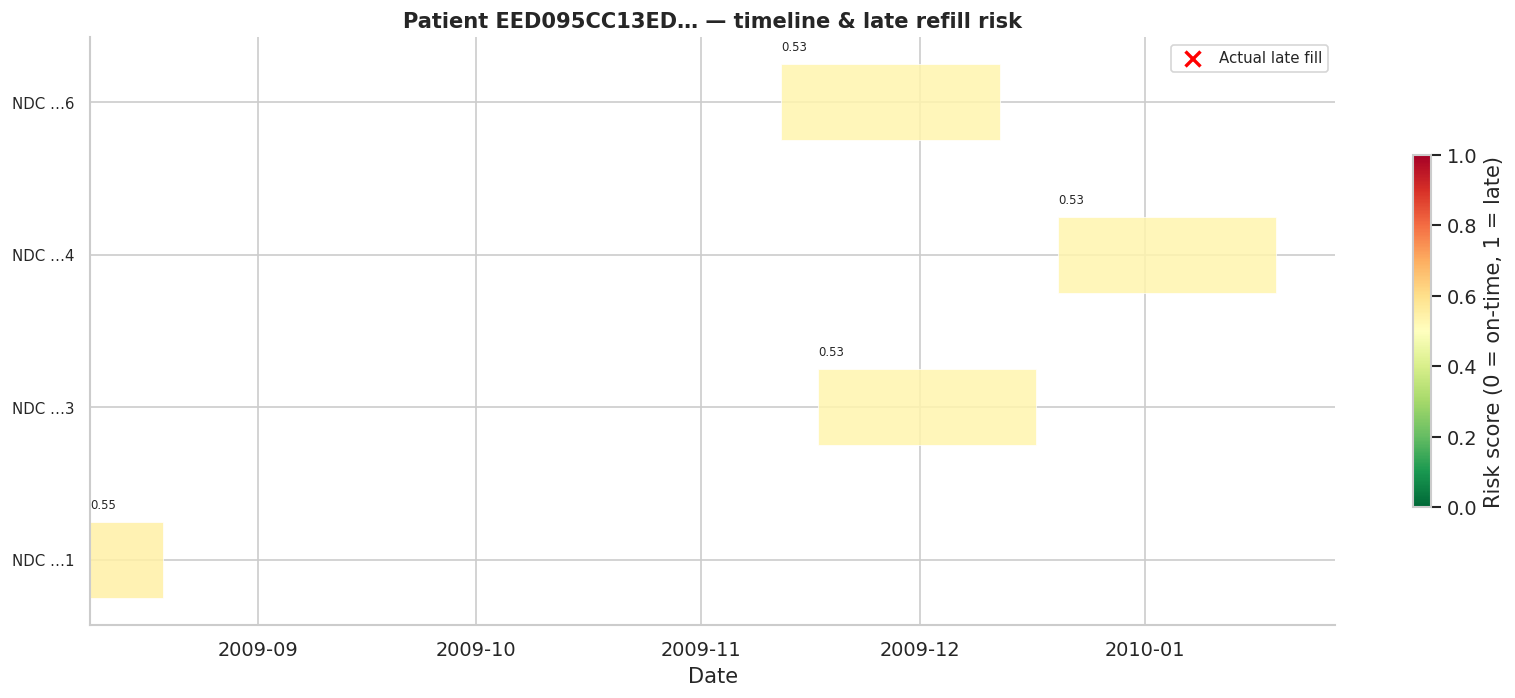

,SRVC_DT,INGREDIENT,DAYS_SUPLY_NUM,gap_days,is_late,risk_score,risk_tier
5012408,2009-08-09 00:00:00,1,10.000000,nan,0,0.549,High
5012414,2009-11-12 00:00:00,6,30.000000,nan,0,0.535,High
5012411,2009-11-17 00:00:00,3,30.000000,nan,0,0.535,High
5012412,2009-12-20 00:00:00,4,30.000000,nan,0,0.535,High


In [24]:
# Pick a high-risk patient for the demo
high_risk_pts = (
    test_scored.groupby('DESYNPUF_ID')['risk_score']
    .mean().sort_values(ascending=False).head(10)
)
print('Top 10 highest mean risk patients:')
print(high_risk_pts.to_string())

demo_patient = high_risk_pts.index[0]
patient_timeline(demo_patient)

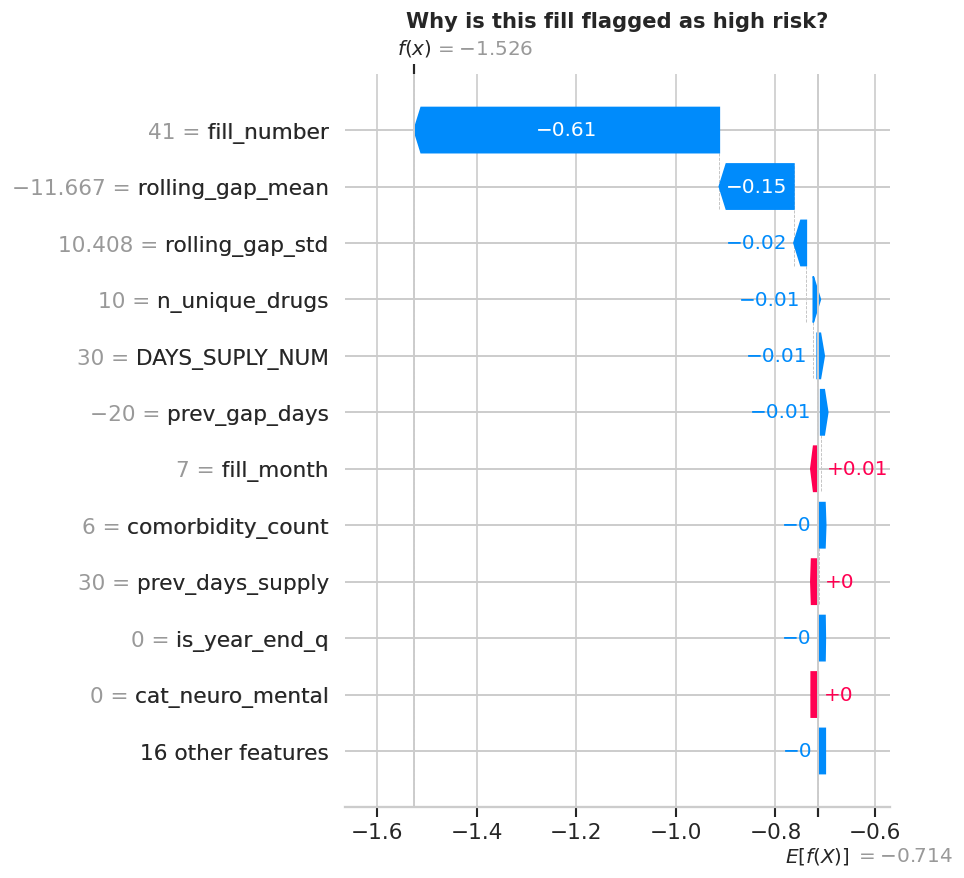

In [25]:
# Single-prediction explanation (waterfall)
# Find the demo patient's first row in the shap sample
demo_rows = test_scored[test_scored['DESYNPUF_ID'] == demo_patient]
sample_matches = shap_sample.index.isin(demo_rows.index)

if sample_matches.any():
    sp_idx = np.where(sample_matches)[0][0]
else:
    sp_idx = 0  # fallback to any row

expected_val = (
    explainer.expected_value[1]
    if isinstance(explainer.expected_value, list)
    else explainer.expected_value
)

shap.waterfall_plot(
    shap.Explanation(
        values        = sv[sp_idx],
        base_values   = expected_val,
        data          = shap_sample.iloc[sp_idx].values,
        feature_names = FEATURE_COLS
    ),
    max_display=12, show=False
)
plt.title('Why is this fill flagged as high risk?', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. Save Outputs

In [26]:
# Scored test set
test_scored[['DESYNPUF_ID', 'SRVC_DT', 'PROD_SRVC_ID',
             'is_late', 'risk_score', 'risk_flag', 'risk_tier']]\
    .to_parquet('test_scored.parquet', index=False)

# Models + feature list
joblib.dump(lgbm,         'model_lgbm.pkl')
joblib.dump(baseline,     'model_baseline.pkl')
joblib.dump(FEATURE_COLS, 'feature_cols.pkl')
joblib.dump({'threshold': best_threshold,
             'grace_days': GRACE_DAYS,
             'split_date': SPLIT_DATE}, 'model_config.pkl')

print('='*48)
print('FINAL RESULTS')
print('='*48)
print(f'  Test fills      : {len(test):,}')
print(f'  Overall late %  : {y_test.mean()*100:.1f}%')
print(f'  Grace window    : {GRACE_DAYS} days')
print(f'  Temporal split  : {SPLIT_DATE}')
print()
print(f'  Baseline PR-AUC : {pr_auc_base:.4f}')
print(f'  LightGBM PR-AUC : {pr_auc_lgbm:.4f}')
print(f'  LightGBM ROC-AUC: {roc_auc_lgbm:.4f}')
print(f'  Brier score     : {brier_score_loss(y_test, y_prob_lgbm):.4f}')
print(f'  Best threshold  : {best_threshold:.3f}')
print('='*48)
print('Saved: test_scored.parquet | model_lgbm.pkl | model_baseline.pkl | model_config.pkl')

FINAL RESULTS
  Test fills      : 2,413,316
  Overall late %  : 17.6%
  Grace window    : 14 days
  Temporal split  : 2009-07-01

  Baseline PR-AUC : 0.3258
  LightGBM PR-AUC : 0.3588
  LightGBM ROC-AUC: 0.7802
  Brier score     : 0.1415
  Best threshold  : 0.268
Saved: test_scored.parquet | model_lgbm.pkl | model_baseline.pkl | model_config.pkl
